In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import Lasso, Ridge ,ElasticNet

In [2]:
df=pd.read_csv(r"C:\Users\Adarsh\Downloads\cleaned_ev_dataset.csv")
df
#loading the datset

,timestamp,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density,charging_demand
0,01-01-2025 00:00,ST004,Two-Wheeler,12.0,60.0,48.984550,99.865576,30.528616,7.0,15.161672,13.66,0.280335,4,Low,17.242398
1,01-01-2025 00:15,ST005,Two-Wheeler,8.0,100.0,58.495493,100.000000,41.504507,50.0,20.997219,5.47,0.392127,3,Low,18.324933
2,01-01-2025 00:30,ST019,Car,11.0,75.0,35.711722,95.733464,45.016306,50.0,31.606151,9.50,0.103979,8,Low,36.028168
3,01-01-2025 00:45,ST008,Two-Wheeler,9.0,40.0,29.270825,100.000000,28.291670,11.0,21.803050,6.22,0.248553,3,Low,17.146935
4,01-01-2025 01:00,ST008,Two-Wheeler,8.0,75.0,25.585554,100.000000,55.810835,11.0,15.626266,13.42,0.234926,5,Low,14.577768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,3/28/2025 23:15,ST011,Bus,13.0,30.0,59.057523,89.414202,9.107004,22.0,19.658234,14.67,0.131198,5,Low,24.557664
8350,3/28/2025 23:30,ST019,Two-Wheeler,12.0,30.0,58.544808,100.000000,12.436558,11.0,30.858874,8.24,0.126224,1,Low,33.027807
8351,3/28/2025 23:45,ST005,Bus,10.0,75.0,33.857844,100.000000,49.606617,7.0,24.068964,9.90,0.370010,4,Low,27.381072
8352,3/29/2025 0:00,ST014,Two-Wheeler,22.0,40.0,28.068288,100.000000,28.772685,22.0,25.992569,14.85,0.105252,6,Low,25.138820


In [3]:
df.head()    # checking top columns


,timestamp,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density,charging_demand
0,01-01-2025 00:00,ST004,Two-Wheeler,12.0,60.0,48.984550,99.865576,30.528616,7.0,15.161672,13.66,0.280335,4,Low,17.242398
1,01-01-2025 00:15,ST005,Two-Wheeler,8.0,100.0,58.495493,100.000000,41.504507,50.0,20.997219,5.47,0.392127,3,Low,18.324933
2,01-01-2025 00:30,ST019,Car,11.0,75.0,35.711722,95.733464,45.016306,50.0,31.606151,9.50,0.103979,8,Low,36.028168
3,01-01-2025 00:45,ST008,Two-Wheeler,9.0,40.0,29.270825,100.000000,28.291670,11.0,21.803050,6.22,0.248553,3,Low,17.146935
4,01-01-2025 01:00,ST008,Two-Wheeler,8.0,75.0,25.585554,100.000000,55.810835,11.0,15.626266,13.42,0.234926,5,Low,14.577768


In [4]:
df.tail()     # checking bottom columns

,timestamp,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density,charging_demand
8349,3/28/2025 23:15,ST011,Bus,13.0,30.0,59.057523,89.414202,9.107004,22.0,19.658234,14.67,0.131198,5,Low,24.557664
8350,3/28/2025 23:30,ST019,Two-Wheeler,12.0,30.0,58.544808,100.000000,12.436558,11.0,30.858874,8.24,0.126224,1,Low,33.027807
8351,3/28/2025 23:45,ST005,Bus,10.0,75.0,33.857844,100.000000,49.606617,7.0,24.068964,9.90,0.370010,4,Low,27.381072
8352,3/29/2025 0:00,ST014,Two-Wheeler,22.0,40.0,28.068288,100.000000,28.772685,22.0,25.992569,14.85,0.105252,6,Low,25.138820
8353,3/29/2025 0:15,ST020,Two-Wheeler,19.0,60.0,31.382711,100.000000,41.170373,50.0,32.816918,7.53,0.246519,9,Low,33.177527


In [5]:
df.describe()
#for statistical representation.

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,charging_demand
count,8270.000000,8270.000000,8354.000000,8354.000000,8354.000000,8270.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.527207,61.064692,34.808452,98.495545,39.079746,22.426723,53.177399,9.959945,0.354101,4.591573,53.156126
std,4.890967,24.987965,14.478839,3.258039,18.973883,16.807544,27.380740,2.878798,0.186150,2.828987,27.563387
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.053024,5.000000,0.100157,0.000000,5.505723
25%,6.000000,40.000000,22.371986,98.463666,23.675251,7.000000,28.029710,7.510000,0.207315,3.000000,27.911603
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,49.421293,9.955000,0.313459,5.000000,49.513337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,77.600445,12.397500,0.462315,7.000000,77.845036
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,100.000000,15.000000,0.799922,15.000000,104.985659


In [6]:
df.isnull().sum()        # finding null value

timestamp                  0
station_id                 0
vehicle_type               0
waiting_time              84
battery_capacity_kWh      84
initial_soc                0
final_soc                  0
energy_consumed_kWh        0
charging_power_kW         84
station_load               0
electricity_price          0
renewable_energy_ratio     0
queue_length               0
traffic_density            0
charging_demand            0
dtype: int64

In [7]:
df.duplicated().sum()      # finding duplicate value

np.int64(0)

In [8]:
df=df.drop(columns=['timestamp'])     # drop the columns

In [9]:
df['waiting_time'] = df['waiting_time'].fillna(df['waiting_time'].median())
df['battery_capacity_kWh'] = df['battery_capacity_kWh'].fillna(df['battery_capacity_kWh'].median())
df['charging_power_kW'] = df['charging_power_kW'].fillna(df['charging_power_kW'].median())

#null value fill by median

In [10]:
df.isnull().sum()   #after fill checking null value

station_id                0
vehicle_type              0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
station_load              0
electricity_price         0
renewable_energy_ratio    0
queue_length              0
traffic_density           0
charging_demand           0
dtype: int64

<Axes: xlabel='waiting_time', ylabel='Count'>

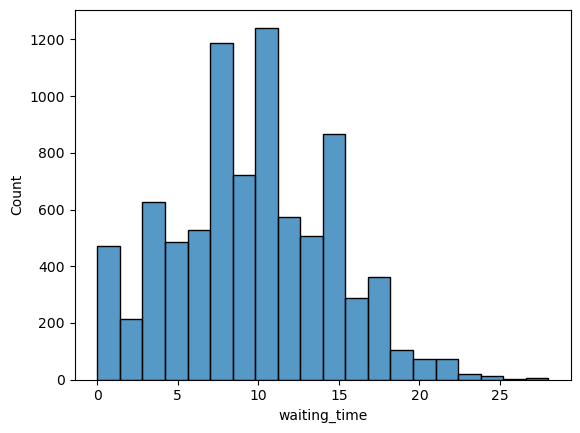

In [11]:
sns.histplot(data=df,x='waiting_time',bins=20)

<Axes: xlabel='vehicle_type', ylabel='count'>

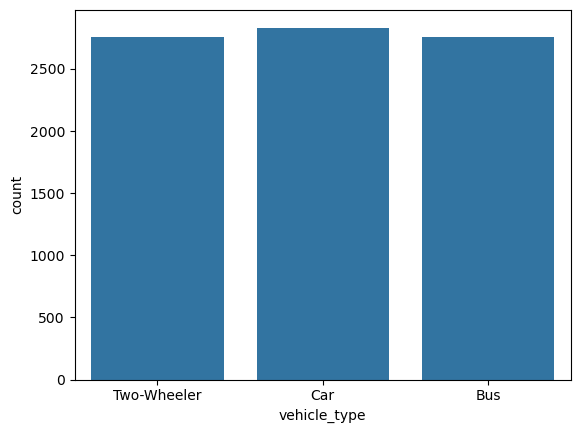

In [12]:
sns.countplot(data=df,x='vehicle_type')

<Axes: ylabel='charging_power_kW'>

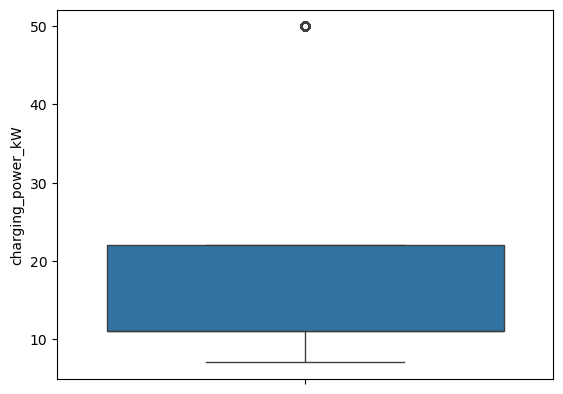

In [13]:
sns.boxplot(data=df,y='charging_power_kW')

In [14]:
df[(df["charging_power_kW"] > 25)][["charging_power_kW"]]

,charging_power_kW
1,50.0
2,50.0
5,50.0
6,50.0
7,50.0
...,...
8334,50.0
8340,50.0
8342,50.0
8348,50.0


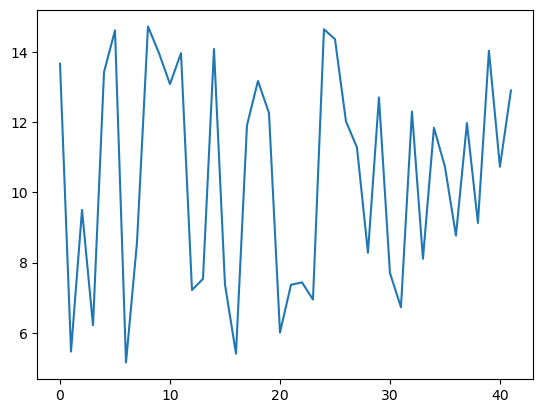

In [15]:
plt.plot(df['electricity_price'].head(42))
plt.show()

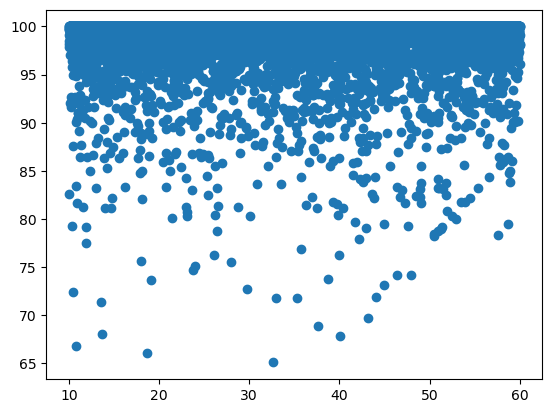

In [16]:
plt.scatter(df["initial_soc"], df["final_soc"]);


<Axes: xlabel='vehicle_type', ylabel='waiting_time'>

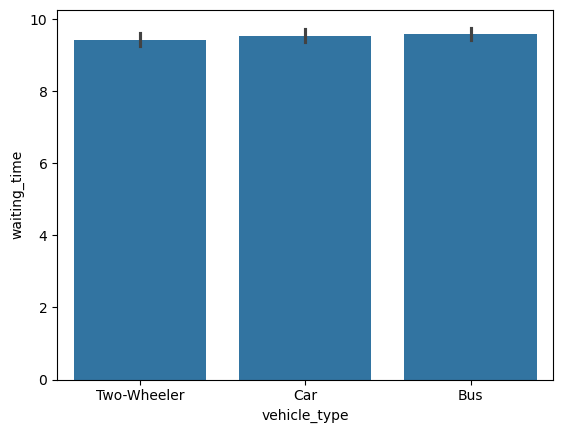

In [17]:
sns.barplot(x="vehicle_type", y="waiting_time", data=df)


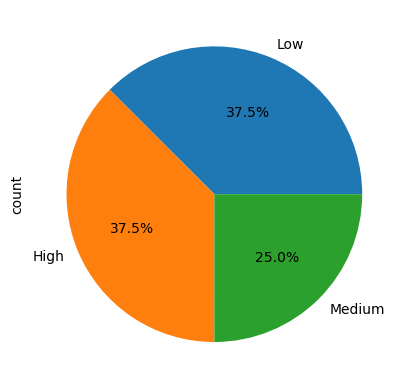

In [18]:
df["traffic_density"].value_counts().plot.pie(autopct='%1.1f%%');


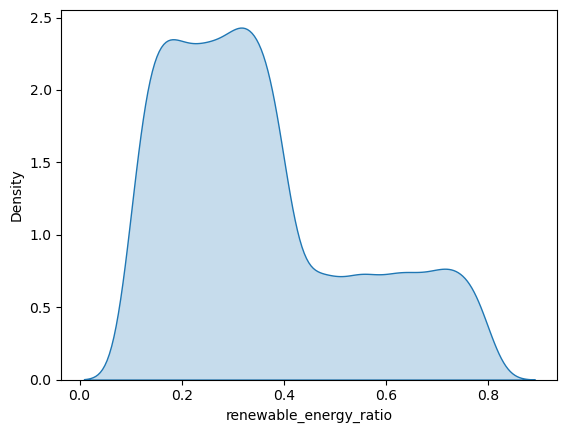

In [19]:
sns.kdeplot(df["renewable_energy_ratio"], fill=True);


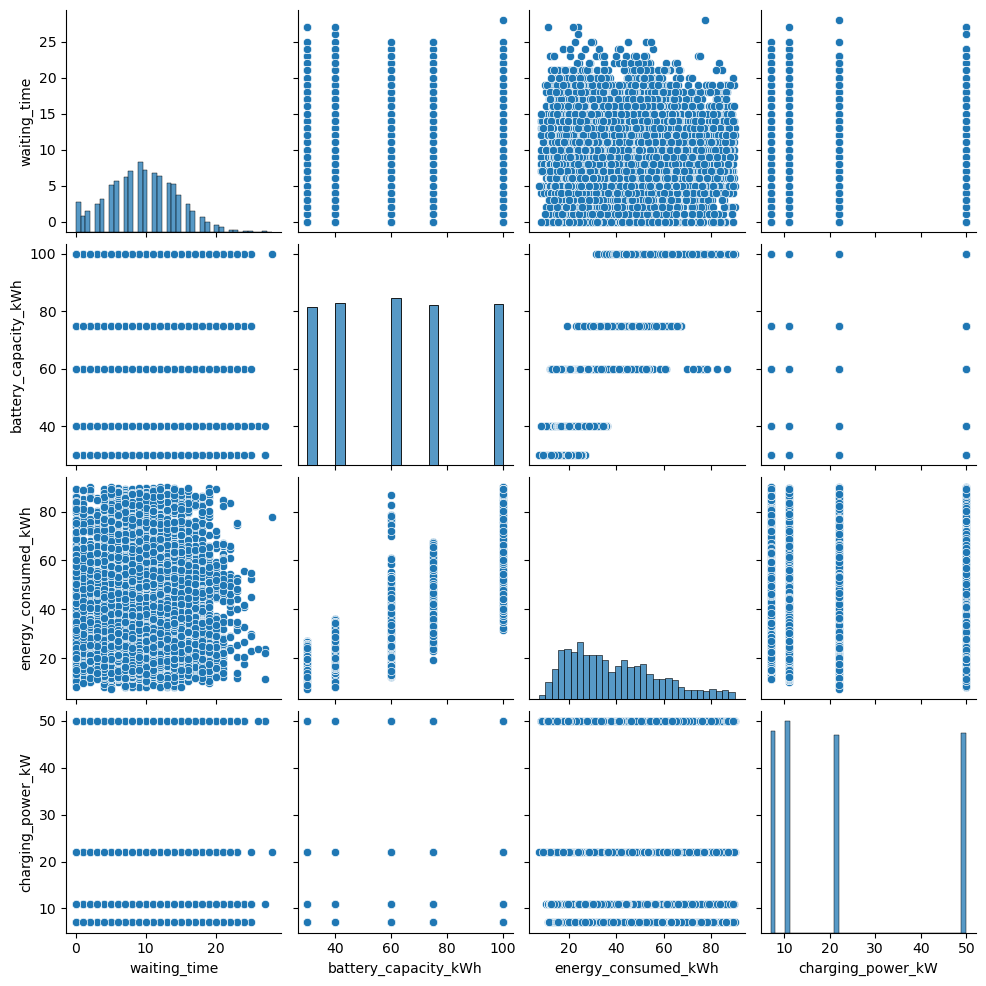

In [20]:
sns.pairplot(df[[ "waiting_time","battery_capacity_kWh","energy_consumed_kWh","charging_power_kW"]]);

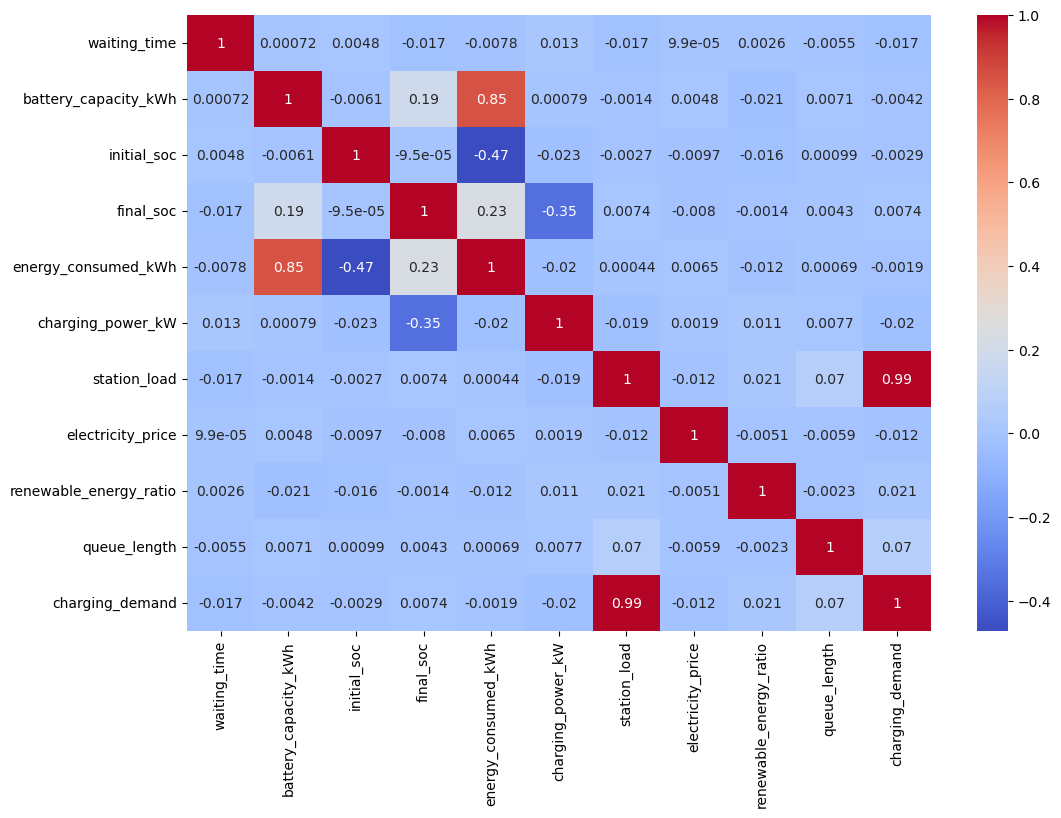

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm");

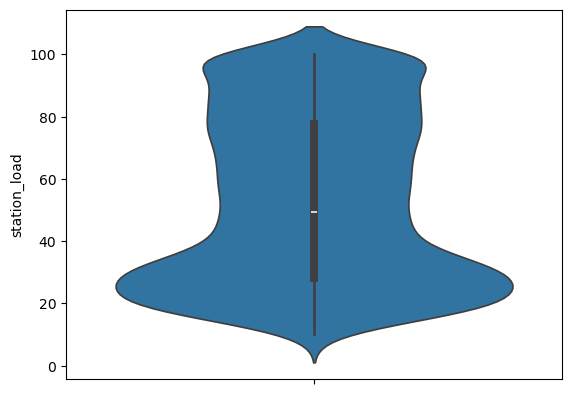

In [22]:
sns.violinplot(y=df["station_load"]);

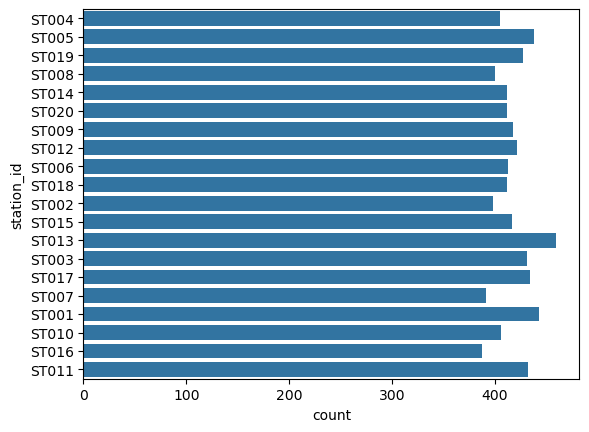

In [23]:
sns.countplot(y="station_id", data=df);

In [24]:
df.columns

Index(['station_id', 'vehicle_type', 'waiting_time', 'battery_capacity_kWh',
       'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW',
       'station_load', 'electricity_price', 'renewable_energy_ratio',
       'queue_length', 'traffic_density', 'charging_demand'],
      dtype='object')

In [25]:
x=df.drop("charging_demand",axis=1)
y=df["charging_demand"]

In [26]:
x

,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density
0,ST004,Two-Wheeler,12.0,60.0,48.984550,99.865576,30.528616,7.0,15.161672,13.66,0.280335,4,Low
1,ST005,Two-Wheeler,8.0,100.0,58.495493,100.000000,41.504507,50.0,20.997219,5.47,0.392127,3,Low
2,ST019,Car,11.0,75.0,35.711722,95.733464,45.016306,50.0,31.606151,9.50,0.103979,8,Low
3,ST008,Two-Wheeler,9.0,40.0,29.270825,100.000000,28.291670,11.0,21.803050,6.22,0.248553,3,Low
4,ST008,Two-Wheeler,8.0,75.0,25.585554,100.000000,55.810835,11.0,15.626266,13.42,0.234926,5,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Bus,13.0,30.0,59.057523,89.414202,9.107004,22.0,19.658234,14.67,0.131198,5,Low
8350,ST019,Two-Wheeler,12.0,30.0,58.544808,100.000000,12.436558,11.0,30.858874,8.24,0.126224,1,Low
8351,ST005,Bus,10.0,75.0,33.857844,100.000000,49.606617,7.0,24.068964,9.90,0.370010,4,Low
8352,ST014,Two-Wheeler,22.0,40.0,28.068288,100.000000,28.772685,22.0,25.992569,14.85,0.105252,6,Low


In [27]:
y

0       17.242398
1       18.324933
2       36.028168
3       17.146935
4       14.577768
          ...    
8349    24.557664
8350    33.027807
8351    27.381072
8352    25.138820
8353    33.177527
Name: charging_demand, Length: 8354, dtype: float64

In [28]:
le = LabelEncoder()

cat_cols = ["station_id", "vehicle_type", "traffic_density"]

for col in cat_cols:
    x[col] = le.fit_transform(x[col])

print(x.head())

   station_id  vehicle_type  waiting_time  battery_capacity_kWh  initial_soc  \
0           3             2          12.0                  60.0    48.984550   
1           4             2           8.0                 100.0    58.495493   
2          18             1          11.0                  75.0    35.711722   
3           7             2           9.0                  40.0    29.270825   
4           7             2           8.0                  75.0    25.585554   

    final_soc  energy_consumed_kWh  charging_power_kW  station_load  \
0   99.865576            30.528616                7.0     15.161672   
1  100.000000            41.504507               50.0     20.997219   
2   95.733464            45.016306               50.0     31.606151   
3  100.000000            28.291670               11.0     21.803050   
4  100.000000            55.810835               11.0     15.626266   

   electricity_price  renewable_energy_ratio  queue_length  traffic_density  
0             

In [29]:
x

,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density
0,3,2,12.0,60.0,48.984550,99.865576,30.528616,7.0,15.161672,13.66,0.280335,4,1
1,4,2,8.0,100.0,58.495493,100.000000,41.504507,50.0,20.997219,5.47,0.392127,3,1
2,18,1,11.0,75.0,35.711722,95.733464,45.016306,50.0,31.606151,9.50,0.103979,8,1
3,7,2,9.0,40.0,29.270825,100.000000,28.291670,11.0,21.803050,6.22,0.248553,3,1
4,7,2,8.0,75.0,25.585554,100.000000,55.810835,11.0,15.626266,13.42,0.234926,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,10,0,13.0,30.0,59.057523,89.414202,9.107004,22.0,19.658234,14.67,0.131198,5,1
8350,18,2,12.0,30.0,58.544808,100.000000,12.436558,11.0,30.858874,8.24,0.126224,1,1
8351,4,0,10.0,75.0,33.857844,100.000000,49.606617,7.0,24.068964,9.90,0.370010,4,1
8352,13,2,22.0,40.0,28.068288,100.000000,28.772685,22.0,25.992569,14.85,0.105252,6,1


In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.80,random_state=42)

In [31]:
x_train

,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density
734,19,0,8.0,60.0,16.428979,99.817248,50.032961,11.0,32.968023,11.91,0.628963,1,2
196,15,1,15.0,40.0,46.622437,96.662615,20.016071,22.0,33.736449,5.52,0.225638,5,1
3213,10,0,16.0,40.0,21.359478,99.197469,31.135197,22.0,45.857232,7.32,0.727507,5,2
3006,18,0,10.0,30.0,51.925067,100.000000,14.422480,7.0,83.178633,6.27,0.135794,6,0
1174,19,0,10.0,40.0,53.536315,100.000000,18.585474,7.0,17.453148,5.12,0.278096,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,15,1,4.0,40.0,31.098168,100.000000,27.560733,7.0,68.000379,14.34,0.381250,4,0
5191,14,2,15.0,75.0,47.693068,100.000000,39.230199,11.0,34.478429,9.67,0.196492,9,1
5390,16,2,0.0,30.0,19.161501,100.000000,24.251550,50.0,23.846802,9.55,0.353351,5,1
860,18,2,7.0,40.0,39.697031,100.000000,24.121188,7.0,11.184832,13.08,0.152858,1,1


In [32]:
x_test

,station_id,vehicle_type,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,station_load,electricity_price,renewable_energy_ratio,queue_length,traffic_density
3532,3,1,9.0,60.0,34.398091,100.000000,49.201432,11.0,86.657460,5.66,0.188598,2,0
8239,4,2,9.0,60.0,30.969513,100.000000,20.709146,11.0,69.751669,8.05,0.176685,3,0
4586,19,2,9.0,60.0,58.540149,100.000000,41.459851,11.0,74.327354,7.79,0.340241,1,0
2795,6,0,9.0,60.0,41.534990,100.000000,43.848757,11.0,18.289377,5.32,0.346203,3,1
5379,2,2,9.0,60.0,30.472513,98.712340,20.471948,11.0,28.211002,8.86,0.378021,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,8,2,17.0,75.0,28.469132,100.000000,53.648151,7.0,100.000000,12.89,0.317018,5,0
5395,10,1,11.0,75.0,40.924267,92.570669,38.734802,50.0,21.873606,14.47,0.147687,3,1
7672,4,0,5.0,75.0,22.767964,100.000000,57.924027,7.0,25.867424,13.74,0.321478,0,1
798,2,0,16.0,75.0,42.110482,100.000000,43.417139,11.0,100.000000,12.77,0.180716,6,0


In [33]:
lr = LinearRegression()

In [34]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
ypredict = lr.predict(x_test)

In [36]:
r2 = r2_score(y_test,ypredict)
r2*100

98.9579006078251

In [37]:
mae = mean_absolute_error(y_test,ypredict)
mae

2.4683348025240894

In [38]:
mse = mean_squared_error(y_test,ypredict)
mse

8.065718005475738

In [39]:
rmse = root_mean_squared_error(y_test,ypredict)
rmse

2.840020775535936

In [40]:
l1 = Lasso()

In [41]:
l1.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [42]:
ypredict1 = l1.predict(x_test)

In [43]:
r2 = r2_score(y_test,ypredict1)
r2*100

98.95652097423964

In [44]:
mae = mean_absolute_error(y_test,ypredict1)
mae

2.4703794308086087

In [45]:
mse = mean_squared_error(y_test,ypredict1)
mse

8.076396195612674

In [46]:
rmse = root_mean_squared_error(y_test,ypredict1)
rmse

2.8419001030318913

In [47]:
l2 =Ridge()

In [48]:
l2.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [49]:
ypredict2=l2.predict(x_test)

In [50]:
r2 = r2_score(y_test,ypredict2)
r2*100

98.95789744234112

In [51]:
mae = mean_absolute_error(y_test,ypredict2)
mae

2.4683406116157145

In [52]:
mse = mean_squared_error(y_test,ypredict2)
mse

8.065742505922975

In [53]:
rmse = root_mean_squared_error(y_test,ypredict2)
rmse

2.8400250889601266

In [54]:
l12 = ElasticNet()

In [55]:
l12.fit(x_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [56]:
ypredict3=l12.predict(x_test)

In [57]:
r2=r2_score(y_test,ypredict3)
r2*100

98.95730707716417

In [58]:
mae = mean_absolute_error(y_test,ypredict3)
mae

2.469347891511249

In [59]:
mse = mean_squared_error(y_test,ypredict3)
mse

8.070311858014774

In [60]:
rmse = root_mean_squared_error(y_test,ypredict3)
rmse

2.840829431348312